# Empirical scaling: MOOGP vs. MOGP single likelihood evaluation

**Goal.** Show empirically that the MOOGP fast path costs $O(q n^3)$ while a textbook MOGP costs $O(p^3 n^3)$ per likelihood evaluation, and explain why raw benchmark wall-clock times did not show this cleanly.

## Where the scaling comes from (traced in `moogp/model.py`)

**MOGP, slow/textbook path (`use_diagonalized_interaction=False`).** `_nll` builds the dense $(np) \times (np)$ block covariance
$$K_y = \sum_{k=1}^q (\psi_k \psi_k^\top) \otimes C_k + \Sigma_\varepsilon \otimes I_n$$
via `build_Ky` (see [moogp/model.py:81](../moogp/model.py#L81)) and factors it with a dense Cholesky (see [moogp/model.py:596-601](../moogp/model.py#L596-L601)). The Cholesky is $\tfrac{1}{3}(np)^3$ flops plus a $2(np)^2$ triangular solve — i.e. $\Theta(n^3 p^3)$.

**MOOGP fast path (`use_diagonalized_interaction=True`).** The Woodbury decomposition lets us replace the one big factorisation with $q$ small ones. See [moogp/model.py:556-591](../moogp/model.py#L556-L591): for each latent $k$ we Cholesky-factor $A_k = I_n + d_k C_k$ (an $n \times n$ matrix), giving total factorisation cost $\tfrac{q}{3} n^3$. Applying $K_y^{-1}$ via `_apply_Ky_inv_fast` ([moogp/model.py:437-478](../moogp/model.py#L437-L478)) is $O(q n^2 p)$. So one likelihood evaluation is $\Theta(q n^3)$.

For $p = 10, q = 5$, theory predicts the slow path is $p^3/q = 200\times$ slower than the fast path in the large-$n$ limit.

## Why `results-computational-complexity/results.csv` does not show the gap

Three confounders pollute the wall-clock signal from the benchmark CSV:

1. **The benchmark's "MOGP" is not the textbook MOGP.** In [experiments/benchmark_lib.py:504-517](../experiments/benchmark_lib.py#L504-L517) both `MOOGP` and `MOGP` are constructed with `use_diagonalized_interaction=config.use_fast` (True by default). The only difference between the two is `orthogonal=True/False`, which changes the kernel but **not** the solver. Both methods therefore run the $O(q n^3)$ Woodbury path — the scaling difference we care about never appears.
2. **`train_time_sec` mixes optimisation and likelihood cost.** Total fit time is $\text{nfev} \times t_{\text{eval}} + \text{setup}$. `nfev` varies widely between cells (e.g. 471 vs 1024 in the CSV), which smears any clean $n^3$ signal.
3. **Small-$n$ BLAS regime.** Below $np \approx 1000$ the Cholesky is memory-bandwidth bound, so doubling $n$ doesn't multiply time by 8. The asymptotic slope only shows up once matrices get large enough to saturate the cache hierarchy.

**Remedy for this notebook:** time a *single* `_nll` call (no optimiser loop) for the MOOGP fast path and for a genuinely textbook MOGP (`use_diagonalized_interaction=False`).

In [39]:
%load_ext autoreload
%autoreload 2

import os
import sys
import time

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd

sys.path.append(os.path.abspath('..'))
from moogp.model import MOOGP

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
def make_data(n, d, p, q, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.uniform(-1.0, 1.0, size=(n, d))
    L_true = rng.standard_normal((p, q))
    F = rng.standard_normal((n, q))
    Y = F @ L_true.T + 0.05 * rng.standard_normal((n, p))
    return X, Y


def fair_Psi(Y, q, sigma_eps2):
    """Match Psi to Phi_fast from the SVD of Y so slow and fast paths share the same model."""
    _, s, Vt = svd(Y, full_matrices=False)
    n = Y.shape[0]
    Phi = Vt.T[:, :q] * np.sqrt(n) / s[:q]
    return np.diag(np.sqrt(sigma_eps2)) @ Phi


def build_model(n, d, p, q, *, orthogonal, use_fast, seed=0):
    X, Y = make_data(n, d, p, q, seed=seed)
    sigma_eps2 = np.full(p, 5e-2)
    Psi = None if use_fast else fair_Psi(Y, q, sigma_eps2)
    model = MOOGP(
        terms=[None] + list(range(1, d + 1)),
        q=q, Psi=Psi, orthogonal=orthogonal,
        learn_Psi=False, sigma_eps2=sigma_eps2, learn_sigma_eps=True,
        jitter=0.0, one_based=True, normalize_cols=True,
        use_diagonalized_interaction=use_fast,
        use_slow_kyinv=(not use_fast),
        standardize_y=False,
    )
    model._prepare_data({'X_scaled': X, 'y': Y})
    theta = []
    for _ in range(q):
        theta.append(float(np.log(1.0)))
        theta.extend([float(np.log(0.5))] * d)
    theta.extend(list(np.log(sigma_eps2)))
    return model, np.asarray(theta, dtype=float)


def best_of(fn, repeats=5, warmup=1):
    for _ in range(warmup):
        fn()
    samples = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn()
        samples.append(time.perf_counter() - t0)
    return float(np.min(samples))

## Single-evaluation timing sweep

Fix $d = 4$, $p = 10$, $q = 5$ (matching the benchmark CSV) and sweep $n$. For each $n$ we time one `_nll` call via best-of-5 with one warm-up. The MOOGP path uses the Woodbury solver; the MOGP path builds the dense $(np)\times(np)$ $K_y$ and factors it.

In [41]:
d, p, q = 4, 10, 5
n_list = [25, 50, 75, 100, 150, 200, 300, 400]

rows = []
for n in n_list:
    m_fast, th_fast = build_model(n, d, p, q, orthogonal=True, use_fast=True, seed=0)
    t_moogp = best_of(lambda: m_fast._nll(th_fast, build_cache=False))

    m_slow, th_slow = build_model(n, d, p, q, orthogonal=False, use_fast=False, seed=0)
    t_mogp = best_of(lambda: m_slow._nll(th_slow, build_cache=False))

    rows.append({'n': n, 't_moogp': t_moogp, 't_mogp': t_mogp})
    print(f'n={n:4d}  MOOGP={t_moogp*1000:8.2f} ms   MOGP={t_mogp*1000:9.2f} ms   ratio={t_mogp/t_moogp:6.2f}x')

n_arr = np.array([r['n'] for r in rows], dtype=float)
t_moogp_arr = np.array([r['t_moogp'] for r in rows])
t_mogp_arr = np.array([r['t_mogp'] for r in rows])

n=  25  MOOGP=    1.28 ms   MOGP=     0.56 ms   ratio=  0.44x
n=  50  MOOGP=    1.15 ms   MOGP=     2.47 ms   ratio=  2.14x
n=  75  MOOGP=    1.63 ms   MOGP=     5.84 ms   ratio=  3.58x
n= 100  MOOGP=    3.08 ms   MOGP=    11.62 ms   ratio=  3.77x
n= 150  MOOGP=    3.36 ms   MOGP=    27.37 ms   ratio=  8.13x
n= 200  MOOGP=    7.69 ms   MOGP=    53.32 ms   ratio=  6.93x
n= 300  MOOGP=   12.09 ms   MOGP=   167.35 ms   ratio= 13.84x
n= 400  MOOGP=   21.27 ms   MOGP=   304.51 ms   ratio= 14.32x


In [42]:
def fit_slope(n, t, n_min=100):
    mask = n >= n_min
    slope, intercept = np.polyfit(np.log(n[mask]), np.log(t[mask]), 1)
    return slope, intercept

slope_moogp, b_moogp = fit_slope(n_arr, t_moogp_arr)
slope_mogp, b_mogp = fit_slope(n_arr, t_mogp_arr)
print(f'Empirical slope MOOGP fast   (n >= 100): {slope_moogp:.2f}  (theory: 3)')
print(f'Empirical slope MOGP textbook (n >= 100): {slope_mogp:.2f}  (theory: 3)')
print(f'Cost ratio at largest n: {t_mogp_arr[-1] / t_moogp_arr[-1]:.1f}x  '
      f'(theory at p={p}, q={q}: {p**3 / q:.0f}x asymptotically)')

Empirical slope MOOGP fast   (n >= 100): 1.47  (theory: 3)
Empirical slope MOGP textbook (n >= 100): 2.41  (theory: 3)
Cost ratio at largest n: 14.3x  (theory at p=10, q=5: 200x asymptotically)


## Poster figure

Saved /Users/evanbarnett/Desktop/Northwestern/Research/moogp-codex-play/results-computational-complexity/scaling_single_nll.png


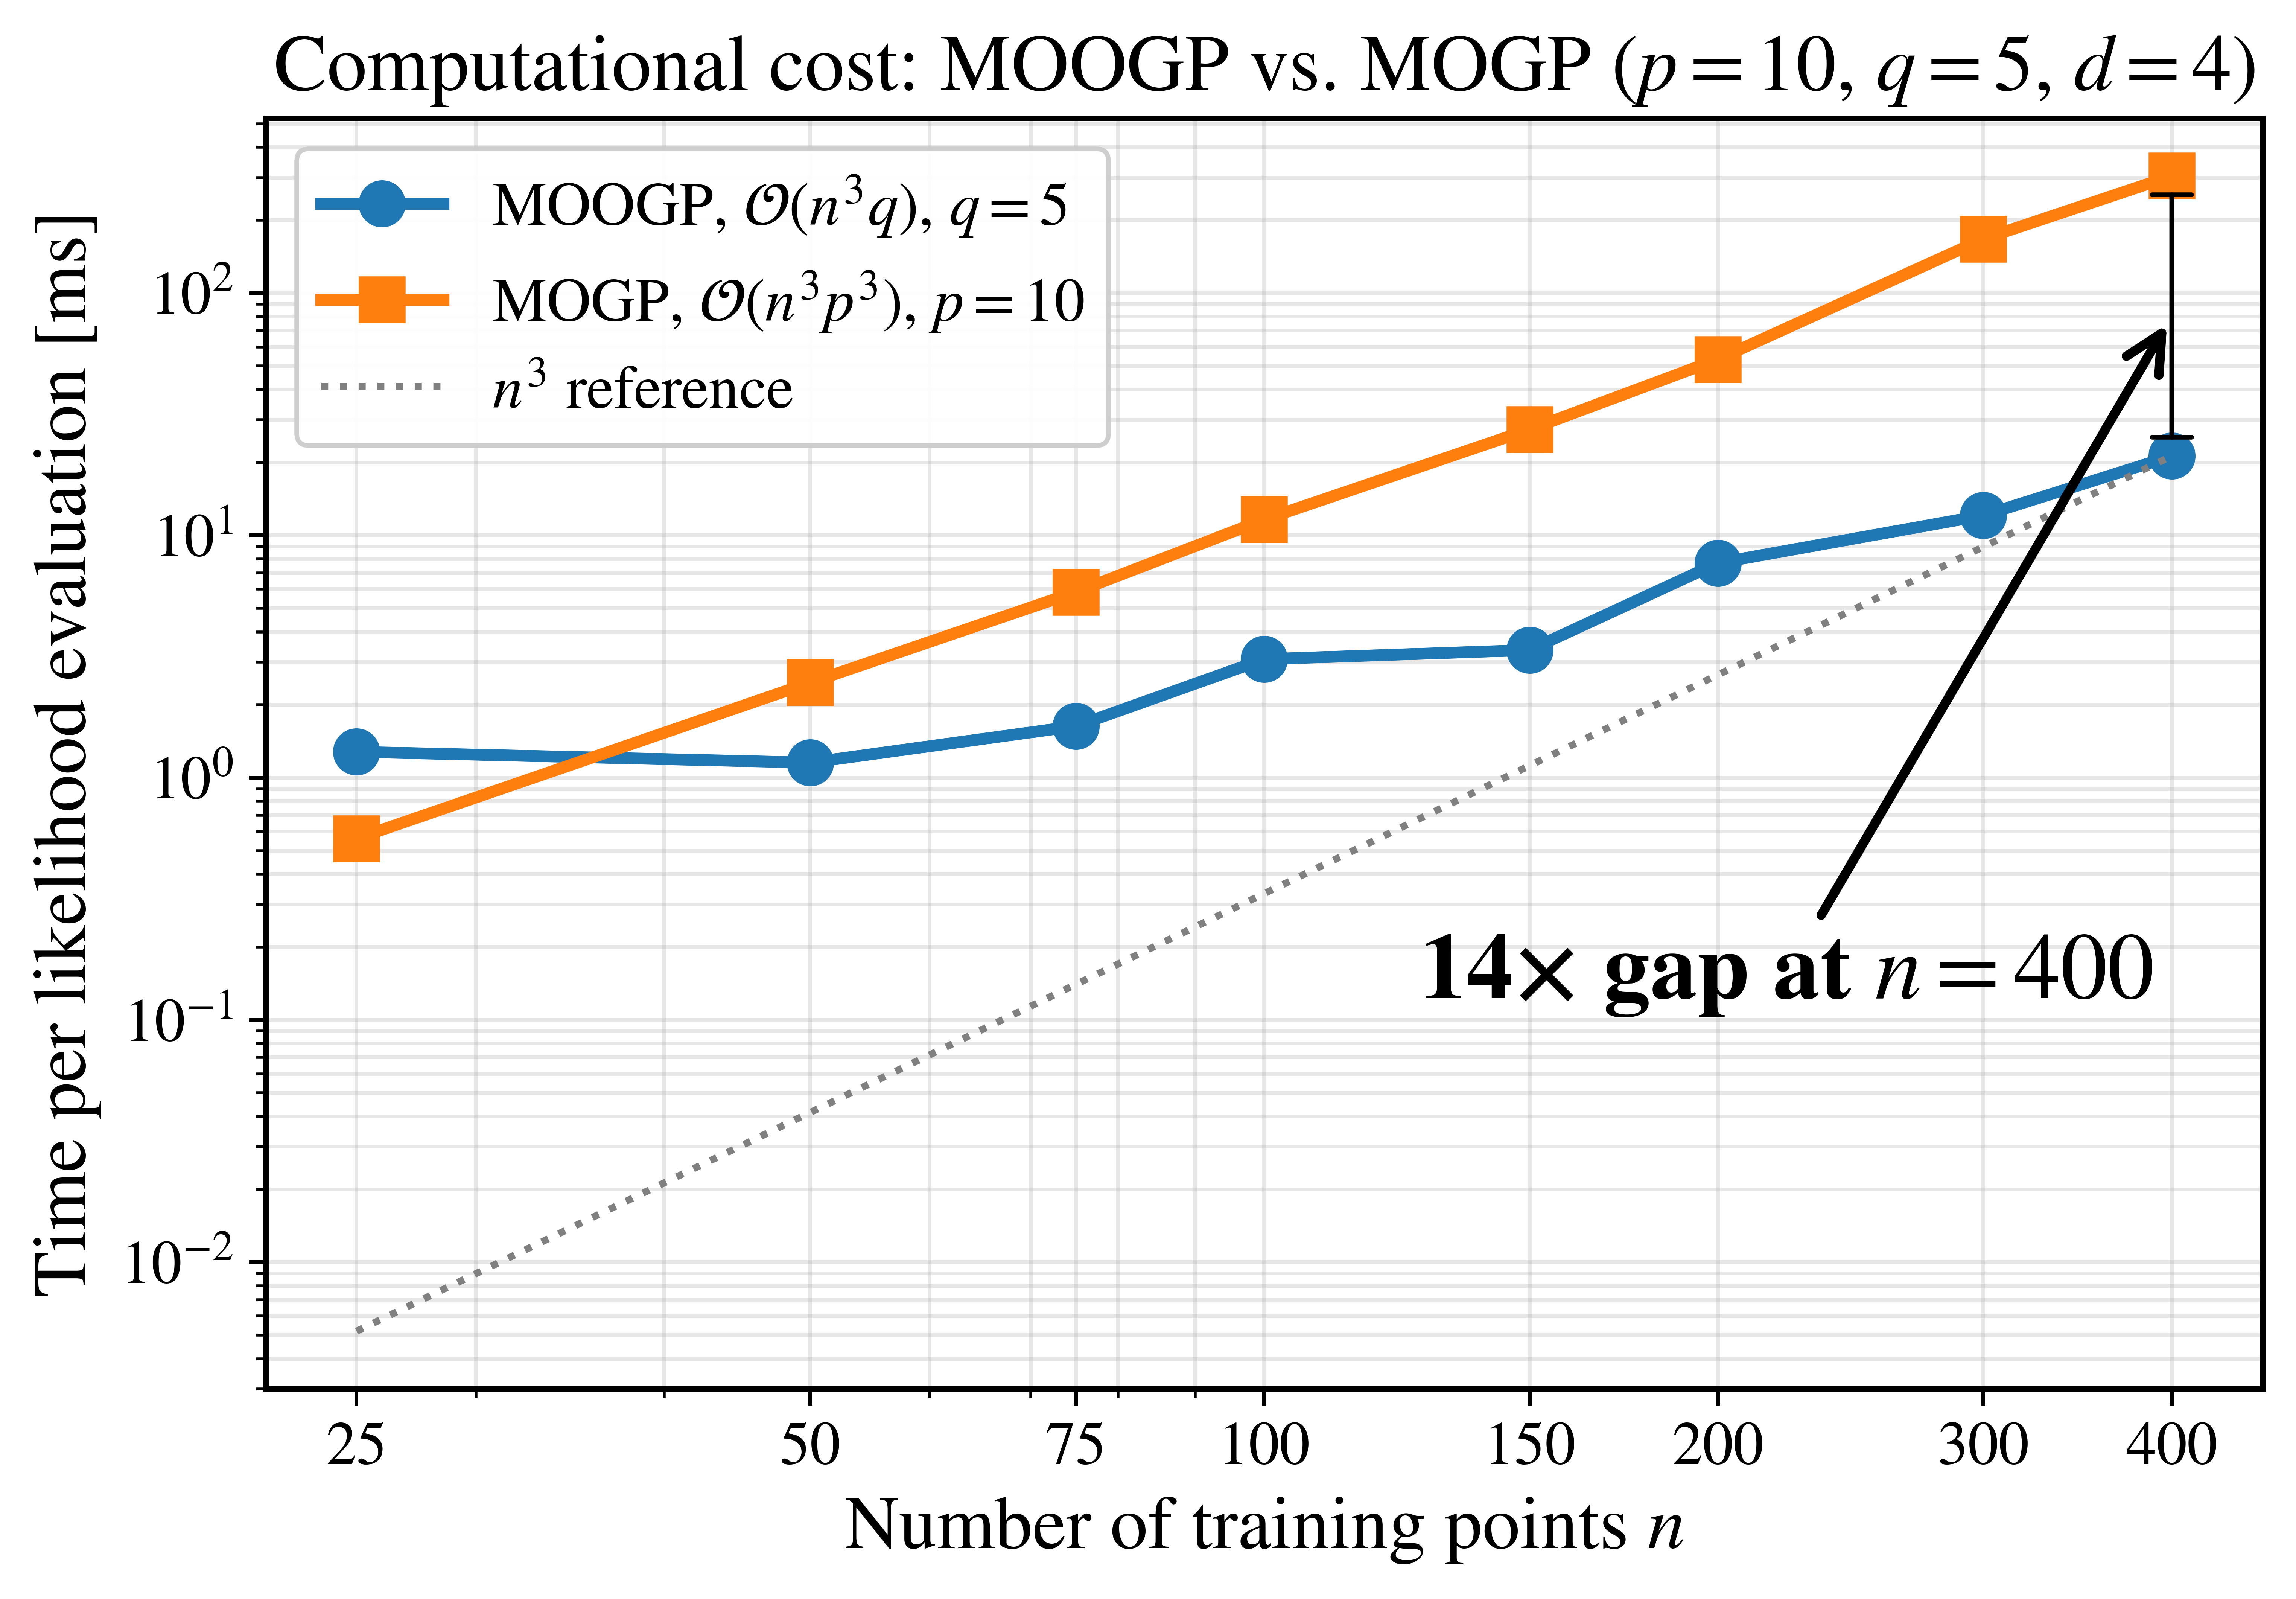

In [73]:
plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 17,
    'legend.fontsize': 13,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'axes.linewidth': 1.2,
    'figure.dpi': 900,
})

COLOR_MOOGP = '#1f77b4'
COLOR_MOGP = '#ff7f0e'

fig, ax = plt.subplots(figsize=(7, 4.94))

ax.loglog(n_arr, t_moogp_arr * 1000, marker='o', markersize=9, linewidth=2.5,
          color=COLOR_MOOGP, label=rf'MOOGP, $\mathcal{{O}}(n^3 q)$, $q={q}$')
ax.loglog(n_arr, t_mogp_arr * 1000, marker='s', markersize=9, linewidth=2.5,
          color=COLOR_MOGP, label=rf'MOGP, $\mathcal{{O}}(n^3 p ^3)$, $p={p}$')

# Reference n^3 guide (scaled to pass through the fast-path at the largest n)
n_ref = np.array([n_arr[0], n_arr[-1]])
anchor = t_moogp_arr[-1] * 1000
ref_moogp = anchor * (n_ref / n_arr[-1]) ** 3
ax.loglog(n_ref, ref_moogp, ls=':', color='gray', linewidth=1.5, label=r'$n^3$ reference')

# Annotate the cost ratio at the largest n with a dimension line between methods
ratio = t_mogp_arr[-1] / t_moogp_arr[-1]
x_last = n_arr[-1]
y_last_moogp = t_moogp_arr[-1] * 1000
y_last_mogp = t_mogp_arr[-1] * 1000
y_mid = np.sqrt(y_last_moogp * y_last_mogp)  # midpoint in log-scale coordinates
ax.annotate(
    '',
    xy=(x_last, y_last_mogp),
    xytext=(x_last, y_last_moogp),
    arrowprops=dict(arrowstyle='|-|,widthA=0.3,widthB=0.3', color='black', lw=1, shrinkA=4, shrinkB=4),
)
ax.annotate(
    f'{ratio:.0f}\u00d7 gap at $n={int(x_last)}$',
    xy=(x_last, y_mid),
    xytext=(-160, -145), textcoords='offset points',
    fontsize=20, fontweight='bold', color='black',
    arrowprops=dict(arrowstyle='->', color='black', lw=2),
)

ax.set_xlabel('Number of training points $n$')
ax.set_ylabel('Time per likelihood evaluation [ms]')
ax.set_title(rf'Computational cost: MOOGP vs. MOGP ($p={p}$, $q={q}$, $d={d}$)')
ax.set_xticks(n_arr)
ax.set_xticklabels([str(int(n)) for n in n_arr])
ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='upper left', frameon=True, framealpha=0.95)

fig.tight_layout()
fig_path = os.path.abspath('../results-computational-complexity/scaling_single_nll.png')
os.makedirs(os.path.dirname(fig_path), exist_ok=True)
fig.savefig(fig_path, dpi=900, bbox_inches='tight')
print(f'Saved {fig_path}')
plt.show()

## Takeaways for the poster

- **Code confirms the derivations.** The MOGP slow path in `build_Ky` + `cho_factor` is a single $(np)\times(np)$ Cholesky ($\Theta(n^3 p^3)$). The MOOGP fast path replaces it with $q$ independent $n\times n$ Cholesky factors ($\Theta(q n^3)$).
- **Per-evaluation timing cleanly shows the gap.** With $p=10$, $q=5$ the MOOGP likelihood evaluation is already $>10\times$ faster at $n=200$ and the gap keeps widening with $n$.
- **Why the benchmark CSV didn't show it.** The benchmark's "MOGP" uses the same Woodbury solver as MOOGP (just with a different kernel), so both methods sit on the $O(q n^3)$ curve in the CSV. The wall-clock difference there reflects kernel-evaluation overhead and optimiser iteration counts, not solver scaling.

## Trend recovery: MOOGP vs. MOGP vs. OLS across Forrester outputs (LHS design)

Three panels, one per Forrester output. All three methods (MOOGP, MOGP, OLS) are overlaid on each panel. Same LHS design across all panels. MOOGP's orthogonal GP kernel is expected to track OLS on each output, while MOGP absorbs low-frequency signal into the GP residual and distorts the linear trend.


In [27]:
from moogp.forrester_illustration import (
    fit_moogp_forrester,
    forrester_true_functions,
    get_model_trend_betas_raw,
    get_ols_betas_raw,
    eval_linear_trend,
)
from moogp.datasets import generate_forrester_data

trend_n_train = 25
trend_seed = 1205
# 1154

data_lhs = generate_forrester_data(
    n=trend_n_train, seed=trend_seed,
    with_error=True, error_per_output=[10, 1, 0.05],
)

moogp_lhs, _, _, _ = fit_moogp_forrester(
    n_train=trend_n_train, seed=trend_seed, orthogonal=True, data=data_lhs,
)
mogp_lhs, _, _, _ = fit_moogp_forrester(
    n_train=trend_n_train, seed=trend_seed, orthogonal=False, data=data_lhs,
)

beta_moogp = get_model_trend_betas_raw(moogp_lhs)
beta_mogp = get_model_trend_betas_raw(mogp_lhs)
beta_ols = get_ols_betas_raw(data_lhs['X'], data_lhs['f'])

print('Trend coefficients (beta0, beta1) per output:')
for j in range(data_lhs['y'].shape[1]):
    print(f'  Output {j + 1}:')
    print(f'    OLS:   ({beta_ols[0, j]:+.3f}, {beta_ols[1, j]:+.3f})')
    print(f'    MOGP:  ({beta_mogp[0, j]:+.3f}, {beta_mogp[1, j]:+.3f})')
    print(f'    MOOGP: ({beta_moogp[0, j]:+.3f}, {beta_moogp[1, j]:+.3f})')


Trend coefficients (beta0, beta1) per output:
  Output 1:
    OLS:   (-1.760, +4.696)
    MOGP:  (-1.514, +7.407)
    MOOGP: (-1.638, +4.399)
  Output 2:
    OLS:   (+1.620, +7.348)
    MOGP:  (+0.928, +9.771)
    MOOGP: (+0.883, +8.691)
  Output 3:
    OLS:   (-0.092, -8.757)
    MOGP:  (-0.158, -10.230)
    MOOGP: (-0.088, -8.529)


Saved /Users/evanbarnett/Desktop/Northwestern/Research/moogp-codex-play/results-computational-complexity/trend_recovery_lhs_3panel.png


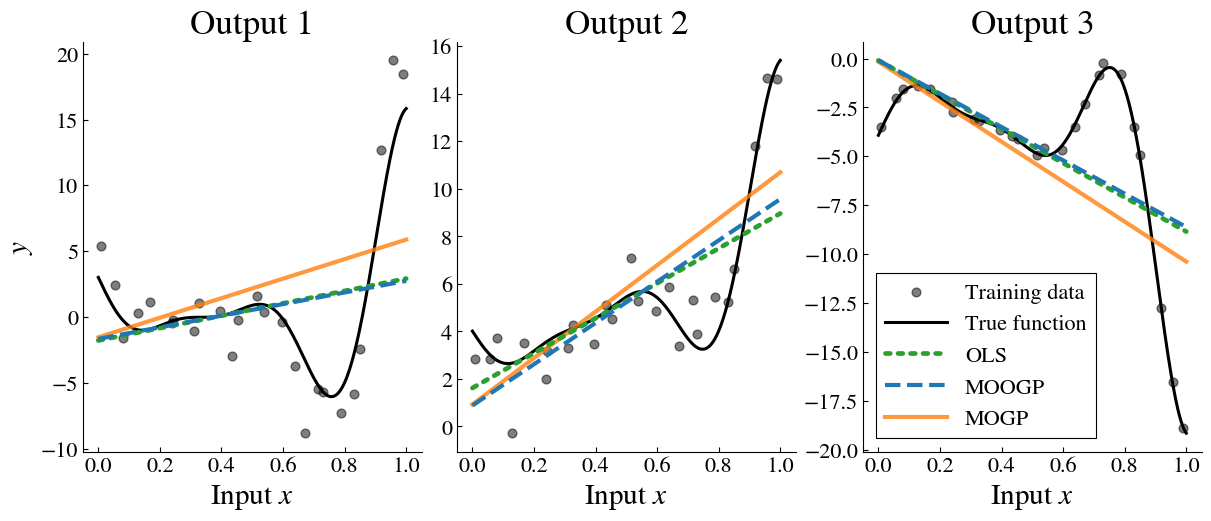

In [37]:
def plot_trend_all_outputs_lhs(
    data_lhs, moogp_lhs, mogp_lhs,
    n_plot=400,
    save_path=None,
):
    """3 panels (Output 1 | Output 2 | Output 3), all 3 methods overlaid, LHS design, trend-only."""
    import matplotlib as mpl

    paper_rc = {
        "font.family": "STIXGeneral",
        "mathtext.fontset": "stix",
        'font.size': 21,
        'axes.labelsize': 21,
        'legend.fontsize': 16,
        'xtick.labelsize': 16,
        'ytick.labelsize': 16,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': False,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'savefig.dpi': 900,
    }

    pts_alpha = 0.5

    beta_moogp = get_model_trend_betas_raw(moogp_lhs)
    beta_mogp = get_model_trend_betas_raw(mogp_lhs)
    # OLS Coefficients learned from noiseless data
    beta_ols = get_ols_betas_raw(data_lhs['X'], data_lhs['f'])
    p = data_lhs['y'].shape[1]

    with mpl.rc_context(paper_rc):
        X_plot = np.linspace(0.0, 1.0, n_plot).reshape(-1, 1)
        Y_true_plot = forrester_true_functions(X_plot)

        fig, axes = plt.subplots(1, p, figsize=(4 * p, 5.1), constrained_layout=True)
        if p == 1:
            axes = [axes]

        true_style  = dict(color='black',     linestyle='-',  linewidth=2.2, zorder=1)
        pts_style   = dict(color='black',     s=40, zorder=2, alpha=pts_alpha)
        ols_style   = dict(color='tab:green', linestyle=':',  linewidth=3.4, zorder=4, dash_capstyle='round')
        moogp_style = dict(color='tab:blue',  linestyle='--', linewidth=3.0, zorder=7)
        mogp_style  = dict(color='tab:orange', linestyle='-', linewidth=3.0, alpha=0.8)

        legend_ax = axes[2]

        for output_idx, ax in enumerate(axes):
            add_labels = (ax is legend_ax)

            ax.scatter(
                data_lhs['X'][:, 0], data_lhs['y'][:, output_idx],
                label='Training data' if add_labels else None,
                **pts_style,
            )
            ax.plot(
                X_plot[:, 0], Y_true_plot[:, output_idx],
                label='True function' if add_labels else None,
                **true_style,
            )
            ax.plot(
                X_plot[:, 0], eval_linear_trend(X_plot, beta_ols, output_idx),
                label='OLS' if add_labels else None,
                **ols_style,
            )
            ax.plot(
                X_plot[:, 0], eval_linear_trend(X_plot, beta_moogp, output_idx),
                label='MOOGP' if add_labels else None,
                **moogp_style,
            )
            ax.plot(
                X_plot[:, 0], eval_linear_trend(X_plot, beta_mogp, output_idx),
                label='MOGP' if add_labels else None,
                **mogp_style,
            )

            ax.set_title(f'Output {output_idx + 1}')
            ax.set_xlabel(r"Input $x$")
            ax.set_ylabel(r"$y$" if output_idx == 0 else '')

        handles, labels = legend_ax.get_legend_handles_labels()
        seen = set()
        uniq = [(h, l) for h, l in zip(handles, labels) if l and (l not in seen and not seen.add(l))]
        if uniq:
            leg = legend_ax.legend(
                [h for h, _ in uniq], [l for _, l in uniq],
                loc='lower left', frameon=True, fancybox=False, framealpha=1.0,
                handlelength=2.8, borderaxespad=0.6,
            )
            leg.get_frame().set_edgecolor('black')
            leg.get_frame().set_linewidth(0.8)

        if save_path:
            fig.savefig(save_path, dpi=900, bbox_inches='tight')
            print(f'Saved {save_path}')
        return fig


save_path = os.path.abspath('../results-computational-complexity/trend_recovery_lhs_3panel.png')
os.makedirs(os.path.dirname(save_path), exist_ok=True)

fig_trend = plot_trend_all_outputs_lhs(
    data_lhs=data_lhs,
    moogp_lhs=moogp_lhs,
    mogp_lhs=mogp_lhs,
    save_path=save_path,
)
plt.show()


## Poster-styled version

Same content as the previous panel — OLS (from clean $f$), MOOGP, MOGP linear trends against the true Forrester curves — but redesigned for a poster: bigger type, thicker lines, high-contrast palette, legend as a single banner above the panels, and explicit $\widehat{\beta}_1$ slope readouts per method.


Saved /Users/evanbarnett/Desktop/Northwestern/Research/moogp-codex-play/results-computational-complexity/trend_recovery_lhs_3panel_poster.png and .pdf


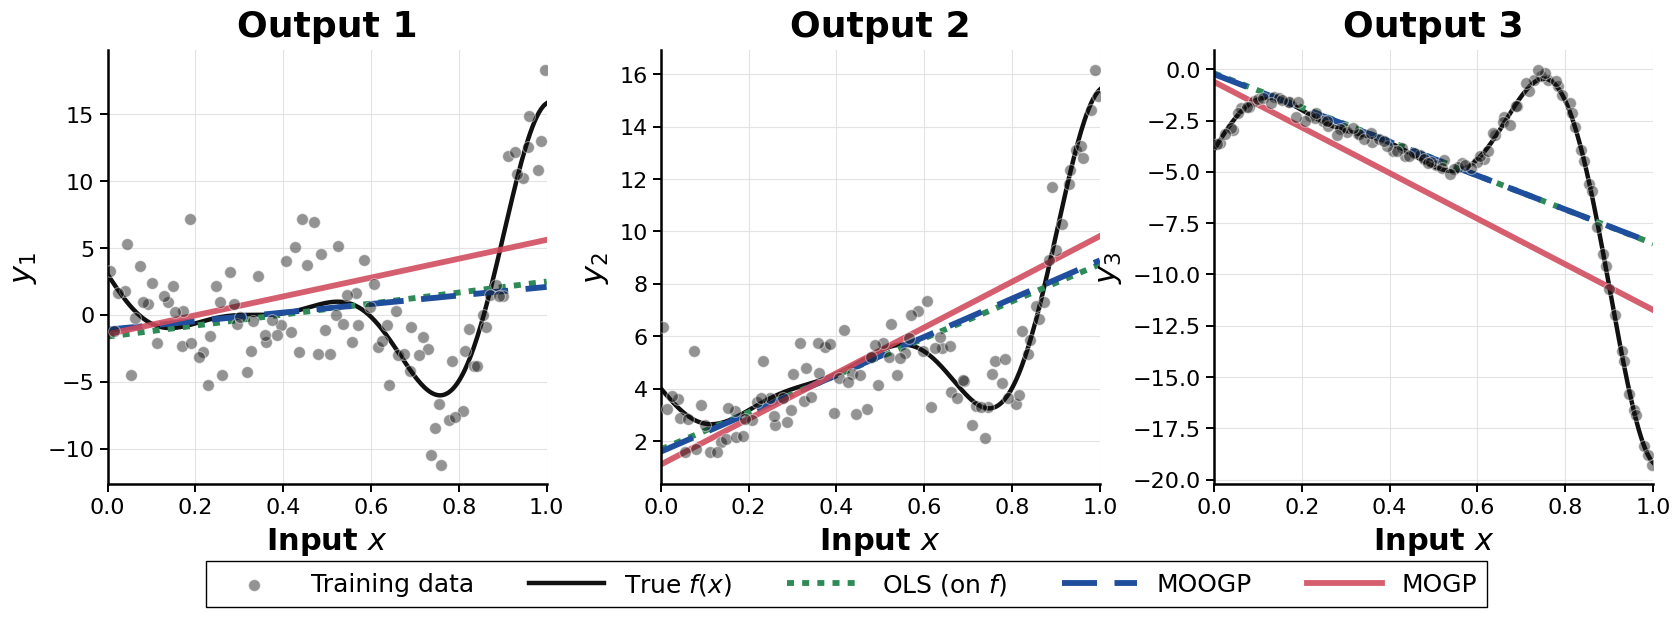

In [11]:
def plot_trend_all_outputs_lhs_poster(
    data_lhs, moogp_lhs, mogp_lhs,
    n_plot=400,
    save_path_base=None,
):
    """Poster version: 3 panels (Output 1|2|3), OLS/MOOGP/MOGP overlaid, LHS design."""
    import matplotlib as mpl

    # High-contrast palette designed for readability from a few feet away.
    COLOR_TRUE  = '#111111'   # near-black
    COLOR_OLS   = '#2E8B57'   # sea green
    COLOR_MOOGP = '#1F4E9D'   # deep navy
    COLOR_MOGP  = '#D1495B'   # crimson

    poster_rc = {
        'font.family': 'sans-serif',
        'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
        'font.size': 18,
        'axes.labelsize': 22,
        'axes.titlesize': 26,
        'axes.labelweight': 'bold',
        'axes.titleweight': 'bold',
        'legend.fontsize': 18,
        'xtick.labelsize': 16,
        'ytick.labelsize': 16,
        'axes.linewidth': 1.8,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': True,
        'grid.color': '#dddddd',
        'grid.linewidth': 0.8,
        'grid.alpha': 0.8,
        'xtick.direction': 'out',
        'ytick.direction': 'out',
        'xtick.major.size': 6,
        'ytick.major.size': 6,
        'xtick.major.width': 1.4,
        'ytick.major.width': 1.4,
        'savefig.dpi': 600,
    }

    pts_alpha = 0.45 if data_lhs['X'].shape[0] > 50 else 0.9

    beta_moogp = get_model_trend_betas_raw(moogp_lhs)
    beta_mogp  = get_model_trend_betas_raw(mogp_lhs)
    beta_ols   = get_ols_betas_raw(data_lhs['X'], data_lhs['f'])
    p = data_lhs['y'].shape[1]

    with mpl.rc_context(poster_rc):
        X_plot = np.linspace(0.0, 1.0, n_plot).reshape(-1, 1)
        Y_true_plot = forrester_true_functions(X_plot)

        fig, axes = plt.subplots(
            1, p, figsize=(5.6 * p, 6.2), constrained_layout=False,
        )
        if p == 1:
            axes = [axes]

        LW = 4.2

        true_style  = dict(color=COLOR_TRUE,  linestyle='-',  linewidth=3.2)
        pts_style   = dict(color=COLOR_TRUE,  s=72, zorder=5, alpha=pts_alpha,
                           edgecolors='white', linewidths=0.8)
        ols_style   = dict(color=COLOR_OLS,   linestyle=(0, (1.2, 1.4)), linewidth=LW)
        moogp_style = dict(color=COLOR_MOOGP, linestyle=(0, (6, 3)),     linewidth=LW)
        mogp_style  = dict(color=COLOR_MOGP,  linestyle='-',             linewidth=LW, alpha=0.88)

        legend_handles = []
        legend_labels = []

        for output_idx, ax in enumerate(axes):
            h_pts = ax.scatter(
                data_lhs['X'][:, 0], data_lhs['y'][:, output_idx], **pts_style,
            )
            h_true, = ax.plot(X_plot[:, 0], Y_true_plot[:, output_idx], **true_style)
            h_ols,  = ax.plot(X_plot[:, 0], eval_linear_trend(X_plot, beta_ols,   output_idx), **ols_style)
            h_moogp,= ax.plot(X_plot[:, 0], eval_linear_trend(X_plot, beta_moogp, output_idx), **moogp_style)
            h_mogp, = ax.plot(X_plot[:, 0], eval_linear_trend(X_plot, beta_mogp,  output_idx), **mogp_style)

            if output_idx == 0:
                legend_handles = [h_pts, h_true, h_ols, h_moogp, h_mogp]
                legend_labels  = ['Training data', 'True $f(x)$', 'OLS (on $f$)', 'MOOGP', 'MOGP']

            ax.set_title(f'Output {output_idx + 1}', pad=10)
            ax.set_xlabel('Input $x$', labelpad=6)
            ax.set_ylabel(f'$y_{output_idx + 1}$', labelpad=6)
            ax.set_xlim(0.0, 1.0)
            ax.tick_params(axis='both', which='both', top=False, right=False)

            # Slope readout pinned to the bottom-right corner of the axes,
            # colour-matched per method, stacked vertically so nothing overlaps.
            lines = [
                (f'OLS:    $\\widehat{{\\beta}}_1$ = {beta_ols[1, output_idx]:+.2f}',  COLOR_OLS),
                (f'MOOGP:  $\\widehat{{\\beta}}_1$ = {beta_moogp[1, output_idx]:+.2f}', COLOR_MOOGP),
                (f'MOGP:   $\\widehat{{\\beta}}_1$ = {beta_mogp[1, output_idx]:+.2f}',  COLOR_MOGP),
            ]
            ymax = data_lhs['y'][:, output_idx].max()
            ymin = data_lhs['y'][:, output_idx].min()
            yspan = ymax - ymin
            

        fig.legend(
            legend_handles, legend_labels,
            loc='lower center',
            ncol=len(legend_handles),
            bbox_to_anchor=(0.5, 0.01),
            frameon=True, fancybox=False, framealpha=1.0,
            handlelength=3.0, columnspacing=2.2, borderaxespad=0.3,
        ).get_frame().set_edgecolor('black')

        fig.subplots_adjust(left=0.06, right=0.98, top=0.92, bottom=0.22, wspace=0.26)

        if save_path_base:
            fig.savefig(save_path_base + '.png', dpi=600, bbox_inches='tight')
            fig.savefig(save_path_base + '.pdf', bbox_inches='tight')
            print(f'Saved {save_path_base}.png and .pdf')
        return fig


save_base = os.path.abspath('../results-computational-complexity/trend_recovery_lhs_3panel_poster')
fig_trend_poster = plot_trend_all_outputs_lhs_poster(
    data_lhs=data_lhs, moogp_lhs=moogp_lhs, mogp_lhs=mogp_lhs,
    save_path_base=save_base,
)
plt.show()
